# 03. Multivariate QTTs and Layouts

## Learning goals

- build QTTs for a two-dimensional target function
- see how quantics bits are arranged in different layouts
- compare bond dimensions between interleaved and grouped layouts
- compare QTT values against exact values on the full grid

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.

In [39]:
using Tensor4all
using CairoMakie

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## A two-dimensional target function

So far we have only worked with functions of one variable. In this notebook we extend the workflow to two dimensions.

The target function is a polynomial-trigonometric mix:

$$f(x, y) = x^2 + x y + y^3 \cos(y)$$

It is smooth on the square domain $[0, 1) \times [0, 1)$ with enough structure to make the layout comparison interesting. We keep `R`, `tolerance`, `maxbonddim`, and `maxiter` explicit so it is clear what the interpolation settings are.

In [40]:
target_function(x, y) = x^2 + x * y + y^3 * cos(y)

target_function (generic function with 1 method)

## Quantics grids in two dimensions

A two-dimensional quantics grid is built from a `DiscretizedGrid{2}`. It assigns $R$ quantics bits to each variable, so there are $2^R$ sample points in each direction and $2^R \times 2^R = 2^{2R}$ points total.

The grid needs variable names and a choice of how the quantics bits are ordered on the tensor train. In this notebook we use $R = 4$ as a moderate resolution, keeping all notebook computations fast.

In [41]:
R = 4
npoints = 1 << R

value_type = Float64
tolerance = 1e-10
maxbonddim = 32
maxiter = 16

grid = QG.DiscretizedGrid(
    (:x, :y), (R, R);
    lower_bound=0.0,
    upper_bound=1.0,
    unfoldingscheme=:interleaved,
    includeendpoint=false,
)

x_coords = [QG.grididx_to_origcoord(grid, (i, 1))[1] for i in 1:npoints]
y_coords = [QG.grididx_to_origcoord(grid, (1, j))[2] for j in 1:npoints]

println("R = $R gives $npoints grid points in each direction.")
println("Domain: [$(x_coords[1]), $(x_coords[end])) x [$(y_coords[1]), $(y_coords[end])).")
println("Total grid points: $(npoints^2).")

R = 4 gives 16 grid points in each direction.
Domain: [0.0, 0.9375) x [0.0, 0.9375).
Total grid points: 256.


The grid display shows the variable names, the indices per site, and the total number of tensor-train cores. For the interleaved layout you can see that the quantics bits alternate between `x` and `y`.

## Interleaved layout

The interleaved layout alternates the quantics bits of the two variables. For this example the tensor-train site order is

$$(x_1,\, y_1,\, x_2,\, y_2,\, x_3,\, y_3,\, x_4,\, y_4)$$

where the subscript is the bit position (most significant first). This layout is the default choice in many one-dimensional QTT workflows extended to two variables: it mixes the variables at every scale.

We build the QTT and measure its accuracy on the full grid.

In [42]:
interleaved_qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    (x, y) -> target_function(x, y),
    grid;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

interleaved_values = [real(interleaved_qtt([i, j])) for i in 1:npoints, j in 1:npoints]
exact_values = [target_function(x_coords[i], y_coords[j]) for i in 1:npoints, j in 1:npoints]
interleaved_max_abs_error = maximum(abs.(exact_values .- interleaved_values))

println("Interleaved QTT built with $R bits per dimension.")
println("Maximum absolute error on the full grid: $interleaved_max_abs_error")

Interleaved QTT built with 4 bits per dimension.
Maximum absolute error on the full grid: 6.661338147750939e-16


## Grouped layout

The grouped layout keeps all quantics bits of one variable together before moving to the next. For this example the site order is

$$(x_1,\, x_2,\, x_3,\, x_4,\, y_1,\, y_2,\, y_3,\, y_4)$$

The represented function values are still the same, but the internal tensor-train structure is different.

We use a separate grid with `unfoldingscheme=:grouped` and build the QTT independently.

In [43]:
grouped_grid = QG.DiscretizedGrid(
    (:x, :y), (R, R);
    lower_bound=0.0,
    upper_bound=1.0,
    unfoldingscheme=:grouped,
    includeendpoint=false,
)

grouped_qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    (x, y) -> target_function(x, y),
    grouped_grid;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

grouped_values = [real(grouped_qtt([i, j])) for i in 1:npoints, j in 1:npoints]
grouped_max_abs_error = maximum(abs.(exact_values .- grouped_values))

println("Grouped QTT built with $R bits per dimension.")
println("Maximum absolute error on the full grid: $grouped_max_abs_error")

Grouped QTT built with 4 bits per dimension.
Maximum absolute error on the full grid: 4.996003610813204e-16


The errors are small for both layouts. The function values are the same; what differs is the internal structure of the tensor train.

## Comparing bond dimensions

The bond-dimension profile tells us how much internal room the QTT needs. Two layouts of the same function can have very different profiles.

We extract the raw cores with `SimpleTT.TensorTrain`, attach indices, and inspect the link dimensions. The worst-case envelope shows the maximum bond dimension a layout of this length could reach.

In [44]:
interleaved_simple = STT.TensorTrain(interleaved_qtt.tci)
interleaved_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(interleaved_simple)]
interleaved_indexed = TN.TensorTrain(interleaved_simple, interleaved_sites)
interleaved_bond_dims = TN.linkdims(interleaved_indexed)

grouped_simple = STT.TensorTrain(grouped_qtt.tci)
grouped_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(grouped_simple)]
grouped_indexed = TN.TensorTrain(grouped_simple, grouped_sites)
grouped_bond_dims = TN.linkdims(grouped_indexed)

println("Interleaved bond dimensions: $interleaved_bond_dims")
println("Grouped bond dimensions:     $grouped_bond_dims")

Interleaved bond dimensions: [2, 4, 4, 6, 6, 4, 2]
Grouped bond dimensions:     [2, 3, 3, 3, 4, 4, 2]


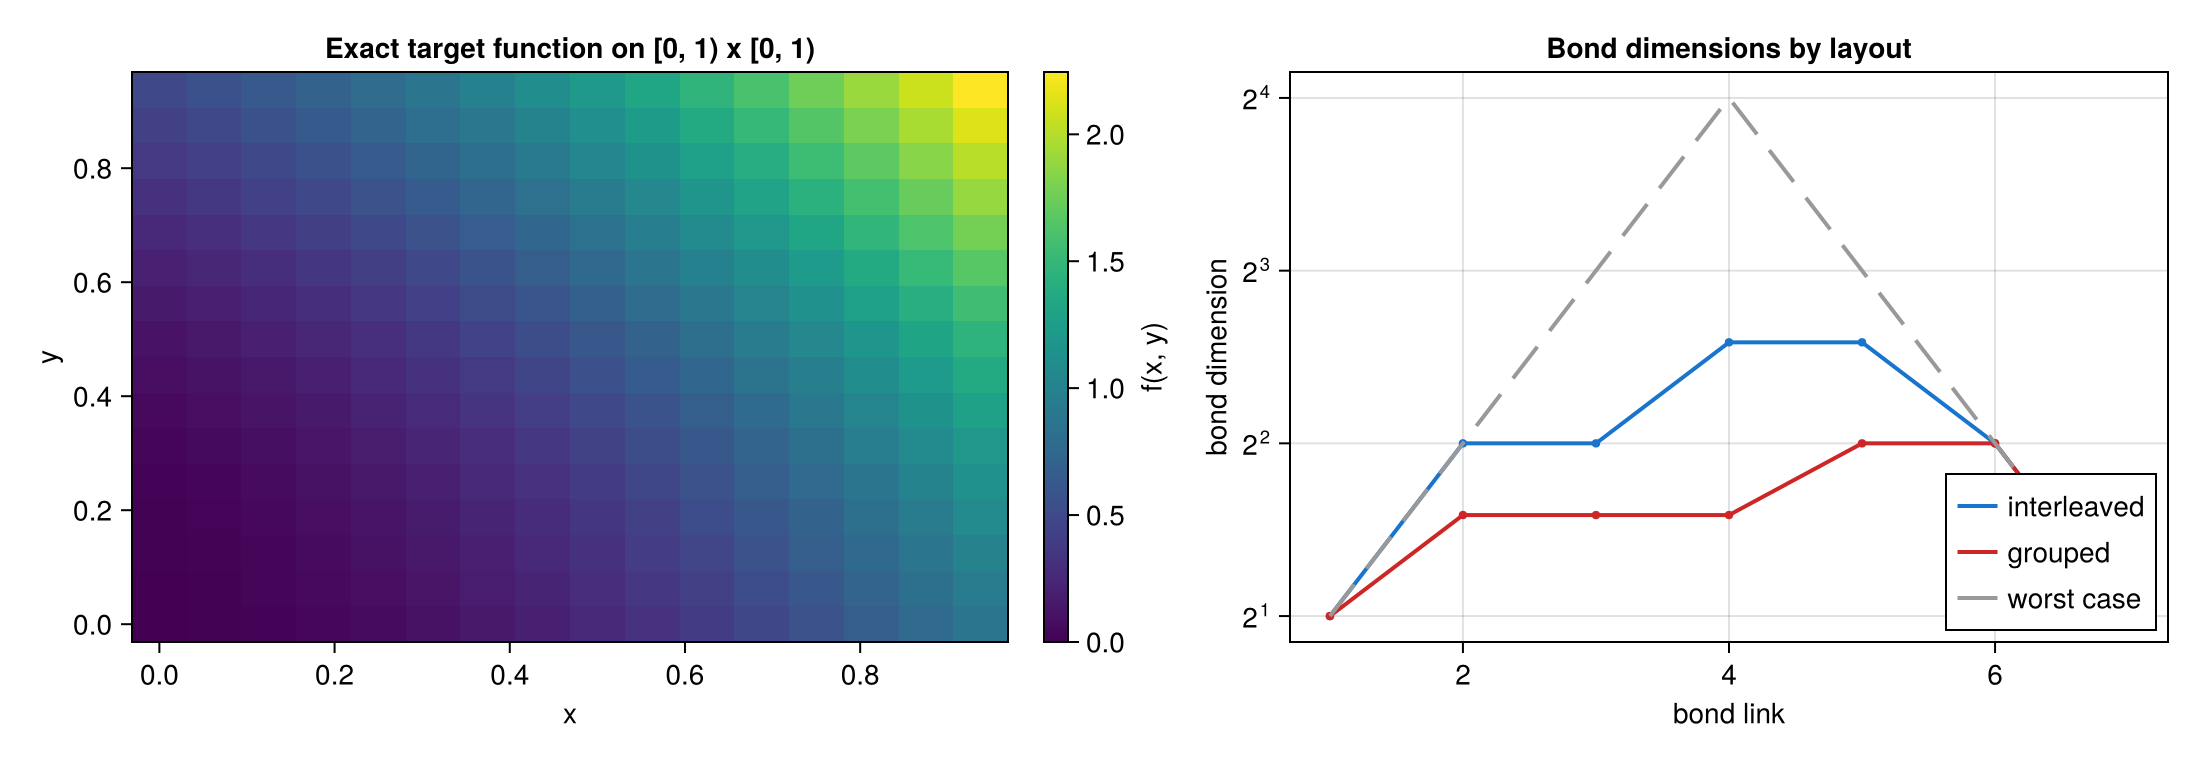

In [45]:
worst_case_bond_dims(num_bonds; base=2) =
    [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

fig = Figure(size=(1100, 380))

ax1 = Axis(
    fig[1, 1],
    xlabel="x",
    ylabel="y",
    title="Exact target function on [0, 1) x [0, 1)",
)
hm = heatmap!(ax1, x_coords, y_coords, exact_values; colormap=:viridis, interpolate=false)
Colorbar(fig[1, 2], hm, label="f(x, y)")

ax2 = Axis(
    fig[1, 3],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimensions by layout",
    yscale=log2,
)
interleaved_bond_index = 1:length(interleaved_bond_dims)
lines!(ax2, interleaved_bond_index, interleaved_bond_dims;
    color=:dodgerblue3, linewidth=2, label="interleaved")
scatter!(ax2, interleaved_bond_index, interleaved_bond_dims;
    color=:dodgerblue3, markersize=6)

grouped_bond_index = 1:length(grouped_bond_dims)
lines!(ax2, grouped_bond_index, grouped_bond_dims;
    color=:firebrick3, linewidth=2, label="grouped")
scatter!(ax2, grouped_bond_index, grouped_bond_dims;
    color=:firebrick3, markersize=6)

worst_profile = worst_case_bond_dims(max(length(interleaved_bond_dims), length(grouped_bond_dims)))
worst_index = 1:length(worst_profile)
lines!(ax2, worst_index, worst_profile;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")

axislegend(ax2; position=:rb)

fig


The left panel shows the exact target function as a heatmap on the 2D grid. The right panel shows the internal bond-dimension profiles.

The two layouts have different profiles even though they target the same function values. Interleaving alternates the bits of `x` and `y`, while grouping keeps all bits of one variable together before moving to the next.

The worst-case envelope shows how large the bond dimensions could be if the function had no compressible structure. Both layouts stay far below this ceiling, confirming that the QTT finds genuine structure in the target function.


## Full-grid evaluation

Both layouts should reconstruct the same function values. The next cell samples a few representative points on the grid and compares interleaved and grouped values with the exact function. Small differences in the last decimal digits are expected from the interpolation tolerance, but the values should agree at the printed precision.

In [46]:
println("Sample comparison (x, y, exact, interleaved, grouped):")
for (i, j) in [(1, 1), (1, npoints), (npoints, 1), (npoints ÷ 2, npoints ÷ 2), (npoints, npoints)]
    x = x_coords[i]
    y = y_coords[j]
    exact = target_function(x, y)
    interleaved = real(interleaved_qtt([i, j]))
    grouped = real(grouped_qtt([i, j]))
    println("  x=$x  y=$y  exact=$exact  interleaved=$interleaved  grouped=$grouped")
end
println()
println("Maximum absolute error (interleaved): $interleaved_max_abs_error")
println("Maximum absolute error (grouped):     $grouped_max_abs_error")

Sample comparison (x, y, exact, interleaved, grouped):
  x=0.0  y=0.0  exact=0.0  interleaved=-1.4770261594336784e-19  grouped=-1.9330670101846618e-16
  x=0.0  y=0.9375  exact=0.4876323555754667  interleaved=0.48763235557546664  grouped=0.4876323555754672
  x=0.9375  y=0.0  exact=0.87890625  interleaved=0.87890625  grouped=0.8789062499999999
  x=0.4375  y=0.4375  exact=0.45866555015016996  interleaved=0.4586655501501699  grouped=0.4586655501501698
  x=0.9375  y=0.9375  exact=2.2454448555754665  interleaved=2.2454448555754665  grouped=2.2454448555754665

Maximum absolute error (interleaved): 6.661338147750939e-16
Maximum absolute error (grouped):     4.996003610813204e-16


Both layouts achieve comparable accuracy. The difference is in the internal structure, not in the final function values.

## Error heatmaps


Checking the absolute error on the full Cartesian grid is a useful complement to the bond-dimension comparison.

Both layouts should reproduce the target function to nearly machine precision on this example. The error heatmaps make that visible across the whole grid, not only at a few sample points.


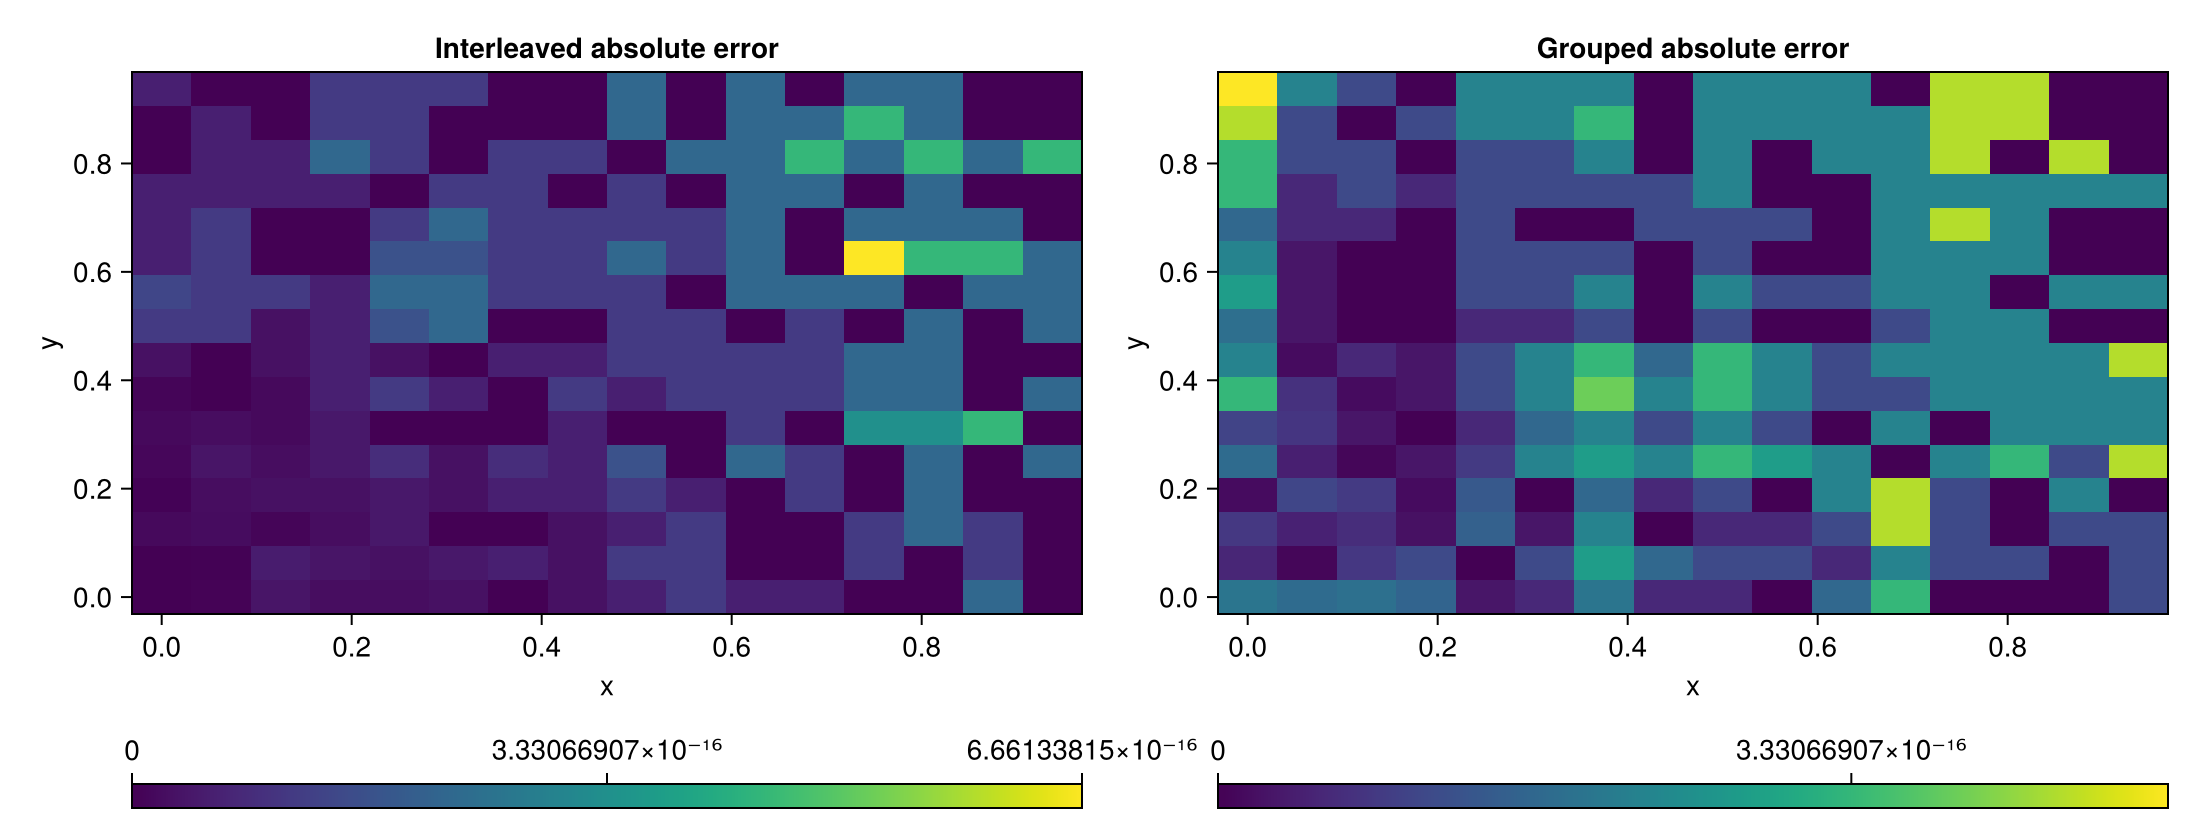

In [47]:
interleaved_abs_error = abs.(exact_values .- interleaved_values)
grouped_abs_error = abs.(exact_values .- grouped_values)

max_error = max(maximum(interleaved_abs_error), maximum(grouped_abs_error))
error_ticks = [0.0, max_error / 2, max_error]

fig = Figure(size=(1100, 420))

ax1 = Axis(
    fig[1, 1],
    xlabel="x",
    ylabel="y",
    title="Interleaved absolute error",
)
hm1 = heatmap!(ax1, x_coords, y_coords, interleaved_abs_error; colormap=:viridis, interpolate=false)
Colorbar(fig[2, 1], hm1; vertical=false, ticks=error_ticks)

ax2 = Axis(
    fig[1, 2],
    xlabel="x",
    ylabel="y",
    title="Grouped absolute error",
)
hm2 = heatmap!(ax2, x_coords, y_coords, grouped_abs_error; colormap=:viridis, interpolate=false)
Colorbar(fig[2, 2], hm2; vertical=false, ticks=error_ticks)

fig


The absolute errors stay tiny across the full grid for both layouts. This confirms that the represented function values agree very well, while the more interesting difference appears in the internal bond-dimension profiles.


This is why the layout question is mainly about internal structure, not about whether one layout reconstructs the sampled values and the other does not.


## What to notice

- A two-dimensional quantics grid has `R` bits per variable, giving `2^R` points in each direction.
- `DiscretizedGrid(variablenames, Rs; unfoldingscheme=...)` lets you choose how quantics bits are ordered on the tensor train.
- Interleaved layout alternates bits from different variables (`x1, y1, x2, y2, ...`).
- Grouped layout keeps all bits of one variable together (`x1, x2, ..., y1, y2, ...`).
- Both layouts reconstruct the same sampled function values to very high accuracy on this example.
- The main difference is in the internal bond-dimension profile, not in the final values.
- The bond-dimension profile tells you something about how the function structure interacts with the chosen layout.


## API recap

- `Tensor4all.QuanticsGrids.DiscretizedGrid(variablenames, Rs; unfoldingscheme)`
- `Tensor4all.QuanticsGrids.grididx_to_origcoord(grid, (i, j))`

- `Tensor4all.QuanticsTCI.quanticscrossinterpolate` (same as in earlier notebooks)
- `Tensor4all.SimpleTT.TensorTrain`
- `Tensor4all.TensorNetworks.TensorTrain`
- `Tensor4all.TensorNetworks.linkdims`